# Week 24 - RAG with LangChain

This notebook implements a **Retrieval-Augmented Generation (RAG)** pipeline from scratch using LangChain. The goal is to be able to ask natural-language questions about the content of a PDF document and get grounded, context-aware answers from a local LLM.

The full pipeline covers:
1. Loading and chunking a PDF document
2. Embedding chunks and storing them in a FAISS vector store
3. Retrieving the most relevant chunks using **dense retrieval + cross-encoder reranking**
4. Prompting a local LLM (DeepSeek-R1) with the retrieved context
5. Evaluating the pipeline with **RAGAS** and plotting results.

## 1. Imports

In [ ]:
import torch
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings, HuggingFacePipeline
from langchain_community.vectorstores import FAISS
from langchain_core.retrievers import BaseRetriever
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain_core.documents import Document
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline as hf_pipeline
from sentence_transformers import CrossEncoder
from pydantic import Field
from typing import Any

# RAG evaluation
from ragas import evaluate, EvaluationDataset, SingleTurnSample
from ragas.metrics import Faithfulness, AnswerRelevancy, ContextRelevance
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import GoogleEmbeddings
from langchain_google_genai import ChatGoogleGenerativeAI
from google import genai
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt

/var/folders/rh/lfgm_qgd69d05qgwcsq20f580000gn/T/ipykernel_75507/1528426572.py:18: DeprecationWarning: Importing Faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import Faithfulness
  from ragas.metrics import Faithfulness, AnswerRelevancy, ContextRelevance
/var/folders/rh/lfgm_qgd69d05qgwcsq20f580000gn/T/ipykernel_75507/1528426572.py:18: DeprecationWarning: Importing AnswerRelevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import AnswerRelevancy
  from ragas.metrics import Faithfulness, AnswerRelevancy, ContextRelevance
/var/folders/rh/lfgm_qgd69d05qgwcsq20f580000gn/T/ipykernel_75507/1528426572.py:18: DeprecationWarning: Importing ContextRelevance from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Exam

## 2. LLM Setup

We load **DeepSeek-R1-Distill-Qwen-1.5B**, a compact reasoning model distilled from DeepSeek-R1. It is small enough to run locally on a GPU (or CPU with float16) while still producing coherent answers.

In [ ]:
model_name = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype = torch.float16, # halves memory usage compared to float32
    device_map = "auto", # lets `accelerate` distribute the model across available hardware automatically
)

pipe = hf_pipeline(
    "text-generation",
    model = model,
    tokenizer = tokenizer,
    max_new_tokens = 512,
    do_sample = True,
    temperature = 0.6,
    return_full_text = False, #return only the newly generated tokens, not the prompt itself
)

llm = HuggingFacePipeline(pipeline=pipe)

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'temperature', 'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


## 3. Embeddings

We use **BGE-small-en-v1.5** from BAAI, a lightweight but high-quality English embedding model. It maps text to a 384-dimensional dense vector and is optimised for retrieval tasks. It runs locally via `sentence-transformers`, so no API calls are needed.

The same embedding model must be used both when **indexing** the document chunks and when **querying**, since both the query and the documents need to live in the same vector space.

In [ ]:
embedding_model = HuggingFaceEmbeddings(model_name = "BAAI/bge-small-en-v1.5")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

## 4. Document Loading

`PyMuPDFLoader` uses the fast **MuPDF** engine to parse the PDF and returns one `Document` object per page. Each `Document` carries the page text in `.page_content` and metadata (file path, page number, etc.) in `.metadata`.

Update `file` to point to any PDF you want to query.

In [ ]:
file = "1-s2.0-S0925231225008100-main.pdf"

loader = PyMuPDFLoader(file)
documents = loader.load()

print(f"Loaded {len(documents)} pages from '{file.split('/')[-1]}'")
print(f"\nSample page metadata: {documents[0].metadata}")
print(f"\nFirst 300 chars of page 1:\n{documents[0].page_content[:300]}")

Loaded 15 pages from '1-s2.0-S0925231225008100-main.pdf'

Sample page metadata: {'producer': 'Acrobat Distiller 8.1.0 (Windows)', 'creator': 'Elsevier', 'creationdate': '2025-05-08T14:31:16+00:00', 'source': '/Users/gonzalo/Documents/Learning/Papers/1-s2.0-S0925231225008100-main.pdf', 'file_path': '/Users/gonzalo/Documents/Learning/Papers/1-s2.0-S0925231225008100-main.pdf', 'total_pages': 15, 'format': 'PDF 1.7', 'title': 'An evolutionary metaheuristic for forming teams in the classroom with constraints', 'author': 'Gonzalo Candel', 'subject': 'Neurocomputing, 638 (2025) 130138. doi:10.1016/j.neucom.2025.130138', 'keywords': 'Team formation,Artificial intelligence,Metaheuristics,Evolutionary algorithm,Teamwork,Classroom', 'moddate': '2025-05-08T14:55:10+00:00', 'trapped': '', 'modDate': 'D:20250508145510Z', 'creationDate': 'D:20250508143116Z', 'page': 0}

First 300 chars of page 1:
Contents lists available at ScienceDirect
Neurocomputing
journal homepage: www.elsevier.com/locate/neucom

## 5. Chunking

LLMs have a finite context window, so we cannot feed an entire document at once. We split documents into overlapping chunks so that:
- Each chunk fits comfortably in the prompt.
- The `chunk_overlap` prevents information from being lost at chunk boundaries — a sentence that spans two chunks will be partially present in both.

`RecursiveCharacterTextSplitter` tries to split on natural boundaries (`\n\n`, `\n`, ` `) before falling back to raw character counts, which tends to produce more semantically coherent chunks than a naive fixed-size split.

| Parameter | Value | Rationale |
|---|---|---|
| `chunk_size` | 1024 | Gives enough context per chunk without bloating the prompt |
| `chunk_overlap` | 128 | ~12% overlap keeps boundary sentences in both adjacent chunks |

In [ ]:
splitter = RecursiveCharacterTextSplitter(chunk_size = 1024, chunk_overlap = 128)
chunks = splitter.split_documents(documents)

print(f"Split {len(documents)} pages into {len(chunks)} chunks")
print(f"Average chunk length: {sum(len(c.page_content) for c in chunks) // len(chunks)} chars")

Split 15 pages into 124 chunks
Average chunk length: 933 chars


## 6. Retrieval with Cross-Encoder Reranking

A standard dense retriever ranks documents by **cosine similarity** between the query embedding and the chunk embeddings. This is fast but imprecise — the bi-encoder models used for embedding are trained to produce a good approximate ranking, not a perfect one.

**Reranking** adds a second, more powerful stage:

1. **First stage (bi-encoder):** FAISS retrieves a larger candidate set (`k=10`) using fast approximate nearest-neighbour search.
2. **Second stage (cross-encoder):** A `CrossEncoder` (`BGE-reranker-base`) scores each `(query, chunk)` pair *jointly*, meaning the full interaction between query and document is modelled. This is slower but far more accurate. We keep only the top `n=3` chunks.

The `RerankedRetriever` class wraps both stages behind LangChain's `BaseRetriever` interface so it can be plugged into any LangChain chain transparently.

In [6]:
class RerankedRetriever(BaseRetriever):
    base_retriever: Any
    model_name: str = Field(default="BAAI/bge-reranker-base")
    top_n: int = Field(default=3)

    def model_post_init(self, __context: Any) -> None:
        # CrossEncoder is not a Pydantic type, so we attach it via object.__setattr__
        # to bypass Pydantic's immutability after initialisation.
        object.__setattr__(self, "_encoder", CrossEncoder(self.model_name))

    def _get_relevant_documents(self, query: str, *, run_manager=None) -> list[Document]:
        # Stage 1: retrieve k=10 candidates from FAISS
        docs = self.base_retriever.invoke(query)

        # Stage 2: score every (query, chunk) pair with the cross-encoder
        pairs = [(query, doc.page_content) for doc in docs]
        scores = self._encoder.predict(pairs)

        # Keep the top_n highest-scoring chunks
        ranked = sorted(zip(scores, docs), key=lambda x: x[0], reverse=True)
        return [doc for _, doc in ranked[: self.top_n]]

## 7. Vector Store

We build a **FAISS** index from the document chunks. FAISS (Facebook AI Similarity Search) stores dense vectors in memory and supports extremely fast approximate nearest-neighbour lookups, making it a good choice for local, single-machine retrieval.

`from_documents` embeds every chunk in one pass and populates the index. We then wrap it in `as_retriever` with `k=10` to get the first-stage candidate set for the reranker.

In [7]:
# Build the FAISS index and wrap with the two-stage retriever
vector_store = FAISS.from_documents(chunks, embedding_model)
base_retriever = vector_store.as_retriever(search_kwargs={"k": 10})

retriever = RerankedRetriever(
    base_retriever=base_retriever,
    model_name="BAAI/bge-reranker-base",
    top_n=3,
)

print("Vector store built and reranking retriever ready.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Vector store built and reranking retriever ready.


## 8. RAG Chain

Now we wire everything together into a single **LCEL** (LangChain Expression Language) chain:

```
query ──► retriever ──► format_docs ──┐
                                       ├──► prompt ──► llm ──► StrOutputParser ──► answer
query ─────────────────────────────────┘
```

- The `retriever | format_docs` branch fetches the top-3 reranked chunks and joins them into a single string for the `{context}` slot.
- `RunnablePassthrough()` passes the raw query string through to the `{question}` slot.
- The prompt includes `<think>\n` at the end to trigger DeepSeek-R1's chain-of-thought mode.
- `StrOutputParser` decodes the model's token output to a plain Python string.

The `ask` helper strips the `<think>...</think>` block from the output and prints only the final answer.

In [8]:
prompt = PromptTemplate.from_template(
    "Use the following context to answer the question.\n\n"
    "Context:\n{context}\n\n"
    "Question: {question}\n<think>\n"
)

def format_docs(docs):
    """Join retrieved chunks into a single context string."""
    return "\n\n".join(doc.page_content for doc in docs)

chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

def ask(query: str) -> None:
    raw = chain.invoke(query)
    # Strip DeepSeek-R1's chain-of-thought block if present
    answer = raw.split("</think>")[-1].strip() if "</think>" in raw else raw
    print(f"Q: {query}\nA: {answer}\n{'-' * 60}\n")

## 9. Running Queries

We run five generic questions against the paper. The questions are intentionally broad so they transfer to any research paper you load — just swap out the PDF path in section 4.

In [9]:
queries = [
    "What is the main research problem addressed in this paper?",
    "What methodology or algorithms does the paper propose?",
    "What datasets or experiments were used to validate the approach?",
    "What are the main conclusions and contributions of the paper?",
    "What are the limitations acknowledged by the authors?",
]

for q in queries:
    ask(q)

[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Q: What is the main research problem addressed in this paper?
A: The main research problem addressed in this paper is the challenge of forming optimal teams in a classroom environment, considering specific constraints such as team size, compulsory and forbidden student combinations, and the need for reliability and robustness in team formation. The solution proposed is an evolutionary algorithm that incorporates mutation, synergy, and local search to address these constraints, ensuring that teams are formed efficiently and effectively.
------------------------------------------------------------



[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: What methodology or algorithms does the paper propose?
A: Okay, so I need to figure out what methodology or algorithms the paper proposes. The paper is about team formation in the classroom, and it mentions several algorithms and approaches. Let me read through the context again.

The context starts by talking about lines of work and 2. Team formation in the classroom. Then it goes into the problem of finding optimal teams, mentioning some authors and algorithms like [18], [19], and [20]. Each of these authors proposes different methods for forming teams.

Looking at the specific algorithms mentioned:
- Deterministic Crowding Genetic Algorithm (DCGA): This is an algorithm that uses genetic algorithms to solve the team formation problem.
- Deterministic Crowding Genetic Algorithm (DCGA): Wait, that's the same as DCGA? Or is it a different one? Maybe it's a typo, and it's another algorithm like DCBA or DCBD.
- Deterministic Crowding Genetic Algorithm (DCGA): Hmm, perhaps it's a differ

[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: What datasets or experiments were used to validate the approach?
A: The datasets used to validate the approach are the Belbin self-perception and Myers-Briggs personality test datasets. These datasets were employed to create the problem instances, which were then used to test the algorithms. The experiments are the problem instances themselves, which were evaluated based on the performance of the algorithms.
------------------------------------------------------------



[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: What are the main conclusions and contributions of the paper?
A: Okay, so I'm trying to figure out the main conclusions and contributions of this paper. I remember that in academic papers, especially those with multiple authors, each section often has specific contributions. Let me break it down step by step.

First, I'll look at the introduction. It usually sets the stage by introducing the topic, mentioning the problem, and stating the objectives. So, the main contribution here is probably explaining the problem and outlining the objectives clearly.

Next, the literature review section. Here, the authors probably summarize existing research, identify gaps, and state the contributions of their study. This section is crucial because it shows that they've done some thorough research and are ahead of others in their field.

Then, the methodology section. This part explains how they conducted their research, the data they used, and the methods they employed. The main contribution here 

[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: What are the limitations acknowledged by the authors?
A: The authors acknowledge several limitations in their approach to team formation, including:

1. **Human Relationships**: They do not explicitly consider human relationships in the classroom, which are crucial for effective team formation.

2. **Constraints Handling**: They mention that they do not fully capture all constraints, though the specifics are unclear. They note that their approach may oversimplify constraints.

3. **Combinations of Students**: The authors do not address the issue of handling combinations of students who must work together or those who must not.

4. **Performance Focus**: While they mention that their
------------------------------------------------------------



## 10. RAGAS Evaluation

[RAGAS](https://docs.ragas.io/) is a framework for automated RAG evaluation. It measures pipeline quality along three axes without needing human-labelled ground truth:

| Metric | What it measures |
|---|---|
| **Faithfulness** | Does the answer contain only information supported by the retrieved context? Detects hallucinations. |
| **Answer Relevancy** | Does the answer actually address the question asked? |
| **Context Relevance** | Are the retrieved chunks relevant to the question? Evaluates retrieval quality independently of generation. |

All three metrics use an LLM (here Gemini) to judge quality, so you need a `GOOGLE_API_KEY` in a `.env` file.

In [12]:
load_dotenv()

genai_client = genai.Client()
ragas_llm = LangchainLLMWrapper(ChatGoogleGenerativeAI(model="gemini-3-flash-preview"))
ragas_embeddings = GoogleEmbeddings(model="text-embedding-004", client=genai_client)

faithfulness = Faithfulness(llm=ragas_llm)
answer_relevancy = AnswerRelevancy(llm=ragas_llm, embeddings=ragas_embeddings)
context_relevance = ContextRelevance(llm=ragas_llm)

samples = []
for q in queries:
    raw = chain.invoke(q)
    answer = raw.split("</think>")[-1].strip() if "</think>" in raw else raw
    docs = retriever.invoke(q)
    contexts = [doc.page_content for doc in docs]
    samples.append(SingleTurnSample(
        user_input=q,
        response=answer,
        retrieved_contexts=contexts,
    ))

dataset = EvaluationDataset(samples=samples)
result = evaluate(
    dataset,
    metrics=[faithfulness, answer_relevancy, context_relevance],
)
result.to_pandas().to_csv("evaluation_results_langchain.csv", index=False)

/var/folders/rh/lfgm_qgd69d05qgwcsq20f580000gn/T/ipykernel_75507/3262711985.py:4: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  ragas_llm = LangchainLLMWrapper(ChatGoogleGenerativeAI(model="gemini-3-flash-preview"))
[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=512) and `max_l

Evaluating:   0%|          | 0/15 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Exception raised in Job[10]: AttributeError('GoogleEmbeddings' object has no attribute 'embed_query')
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
Exception raised in Job[1]: AttributeError('GoogleEmbeddings' object has no attribute 'embed_query')


An error occurred: Error calling model 'gemini-3-flash-preview' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-3-flash\nPlease retry in 28.212915666s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerMinutePerProjectPerModel-FreeTier'

Exception raised in Job[0]: TimeoutError()
Exception raised in Job[3]: TimeoutError()
Exception raised in Job[4]: TimeoutError()
Exception raised in Job[7]: TimeoutError()
Exception raised in Job[9]: TimeoutError()
Exception raised in Job[12]: TimeoutError()
Exception raised in Job[13]: TimeoutError()


## 11. Evaluation Results Analysis

We load `evaluation_results_langchain.csv` produced in the previous section and inspect the results across three dimensions:

- **Per-metric summary** — mean / min / max for each RAGAS metric across all questions.
- **Grouped bar chart** — compares all three scores side-by-side for each question, making it easy to spot which question is systematically weak.
- **Heatmap** — provides the same information in a compact grid form, colour-coded from red (0) to green (1).
- **Extreme pairs** — surfaces the lowest- and highest-scoring `(question, metric)` pairs to guide targeted improvements.

> As a rough rule of thumb, scores above **0.7** are generally considered acceptable; below **0.5** indicates a meaningful problem worth investigating.

In [ ]:
df = pd.read_csv("evaluation_results_langchain.csv")
metrics = ["faithfulness", "answer_relevancy", "nv_context_relevance"]

# Add a short label for each question
df["Q"] = [f"Q{i+1}" for i in range(len(df))]

# Display table with truncated question text
display_df = df[["Q", "user_input"] + metrics].copy()
display_df["user_input"] = display_df["user_input"].str[:65] + "\u2026"
display_df = display_df.rename(columns={"user_input": "Question"})
display_df = display_df.set_index("Q")
display_df

,Question,faithfulness,answer_relevancy,nv_context_relevance
Q,,,,
Q1,What is the main research problem addressed in...,NaN,NaN,NaN
Q2,What methodology or algorithms does the paper ...,NaN,NaN,NaN
Q3,What datasets or experiments were used to vali...,0.75,NaN,NaN
Q4,What are the main conclusions and contribution...,NaN,NaN,NaN
Q5,What are the limitations acknowledged by the a...,NaN,NaN,NaN


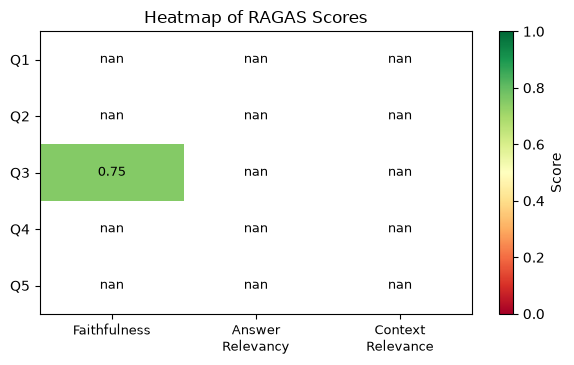

In [16]:
# Heatmap — questions × metrics, colour-coded from red (0) to green (1)
pivot = df.set_index("Q")[metrics]

fig, ax = plt.subplots(figsize=(6, len(df) * 0.55 + 1))
im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)

col_labels = ["Faithfulness", "Answer\nRelevancy", "Context\nRelevance"]
ax.set_xticks(range(len(metrics)))
ax.set_xticklabels(col_labels, fontsize=9)
ax.set_yticks(range(len(df)))
ax.set_yticklabels(df["Q"])

# Annotate each cell with its value
for i in range(len(df)):
    for j in range(len(metrics)):
        val = pivot.values[i, j]
        text_color = "white" if val < 0.3 or val > 0.85 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=9, color=text_color)

plt.colorbar(im, ax=ax, label="Score")
ax.set_title("Heatmap of RAGAS Scores")
plt.tight_layout()
plt.show()